# Model Interpretation & Research Findings

## Introduction

The previous notebook identified the tuned Random Forest model as the best-performing model for predicting next-day Air Quality Index (AQI). While the model achieved strong predictive performance, understanding *why* the model makes its predictions is equally important.

This notebook focuses on interpreting the final model using feature importance and SHAP (SHapley Additive exPlanations). These techniques help identify the most influential variables and explain how biomass burning, meteorological conditions, and historical pollution contribute to next-day AQI prediction. The findings are then used to address the research objectives and hypotheses of the study.

## 2. Import Required Libraries

The libraries required for model interpretation and visualization are imported.

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import shap

from sklearn.ensemble import RandomForestRegressor

## 3. Load the Feature Engineered Dataset

The feature-engineered dataset developed in the previous notebooks is loaded for model interpretation.

In [5]:
feature_df = pd.read_csv(
    "feature_engineered_dataset.csv"
)

feature_df.head()

,Date,AQI,AQI_Bucket,PM2.5,Fire_Count,Total_FRP,Mean_FRP,Max_FRP,Mean_U10,Mean_V10,...,AQI_lag1,AQI_lag2,AQI_lag3,AQI_rolling_mean_3,AQI_rolling_std_3,Fire_Count_lag1,Fire_Count_lag2,Total_FRP_lag1,Total_FRP_lag2,AQI_next_day
0,2015-01-04,319.0,Very Poor,151.84,15,81.51,5.434000,15.46,1.773298,-1.831503,...,143.0,454.0,472.0,356.333333,184.971169,4.0,15.0,5.93,84.92,325.0
1,2015-01-05,325.0,Very Poor,146.60,34,110.50,3.250000,8.84,4.105233,-2.425379,...,319.0,143.0,454.0,305.333333,155.949778,15.0,4.0,81.51,5.93,318.0
2,2015-01-06,318.0,Very Poor,149.58,27,78.98,2.925185,5.09,1.927311,-1.480514,...,325.0,319.0,143.0,262.333333,103.389232,34.0,15.0,110.50,81.51,353.0
3,2015-01-07,353.0,Very Poor,217.87,5,14.42,2.884000,3.44,0.352872,-1.366974,...,318.0,325.0,319.0,320.666667,3.785939,27.0,34.0,78.98,110.50,383.0
4,2015-01-08,383.0,Very Poor,229.90,10,62.42,6.242000,17.37,0.695696,-1.075948,...,353.0,318.0,325.0,332.000000,18.520259,5.0,27.0,14.42,78.98,375.0


## 4. Environmental Feature Dataset

To better understand the contribution of biomass burning and meteorological variables, two variables representing the current pollution state (`AQI` and `PM2.5`) are excluded from this analysis.

Since these variables already summarize the current air quality, they dominate the feature importance analysis. Removing them allows the relative contribution of environmental variables to be examined more clearly while leaving the predictive modelling results unchanged.

In [6]:
X_env = feature_df.drop(
    columns=[
        "Date",
        "AQI_next_day",
        "AQI",
        "PM2.5",
        "AQI_Bucket"
    ]
)

y = feature_df["AQI_next_day"]

In [7]:
print(X_env.shape)

(1847, 23)


## 5. Chronological Train-Test Split

The environmental feature dataset is divided into chronological training and testing subsets using the same 80:20 split employed during model development. Using an identical split ensures that the interpretation remains consistent with the final predictive model while preserving the temporal order of the observations.

In [8]:
split_index = int(len(feature_df) * 0.8)

X_train = X_env.iloc[:split_index]
X_test = X_env.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

## 6. Environmental Random Forest Model

A Random Forest model is trained using the optimal hyperparameters identified in the machine learning notebook. The current AQI and PM2.5 variables are intentionally excluded so that the relative importance of biomass burning, meteorological conditions, and historical AQI features can be investigated more clearly.

In [9]:
env_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

env_rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 7. Environmental Feature Importance

Feature importance is calculated for the environmental Random Forest model. By excluding the dominant pollution indicators, this analysis provides a clearer understanding of the relative contribution of biomass burning, meteorological conditions, temporal variables, and historical AQI features to next-day AQI prediction.

In [10]:
env_feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": env_rf.feature_importances_
})

env_feature_importance = env_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

env_feature_importance

,Feature,Importance
14,AQI_lag1,0.451258
17,AQI_rolling_mean_3,0.192276
7,Max_Wind_Speed,0.070639
9,Avg_DewPoint_C,0.036493
4,Mean_U10,0.033340
5,Mean_V10,0.020088
6,Mean_Wind_Speed,0.017869
10,Relative_Humidity,0.016744
16,AQI_lag3,0.015705
8,Avg_Temperature_C,0.014005


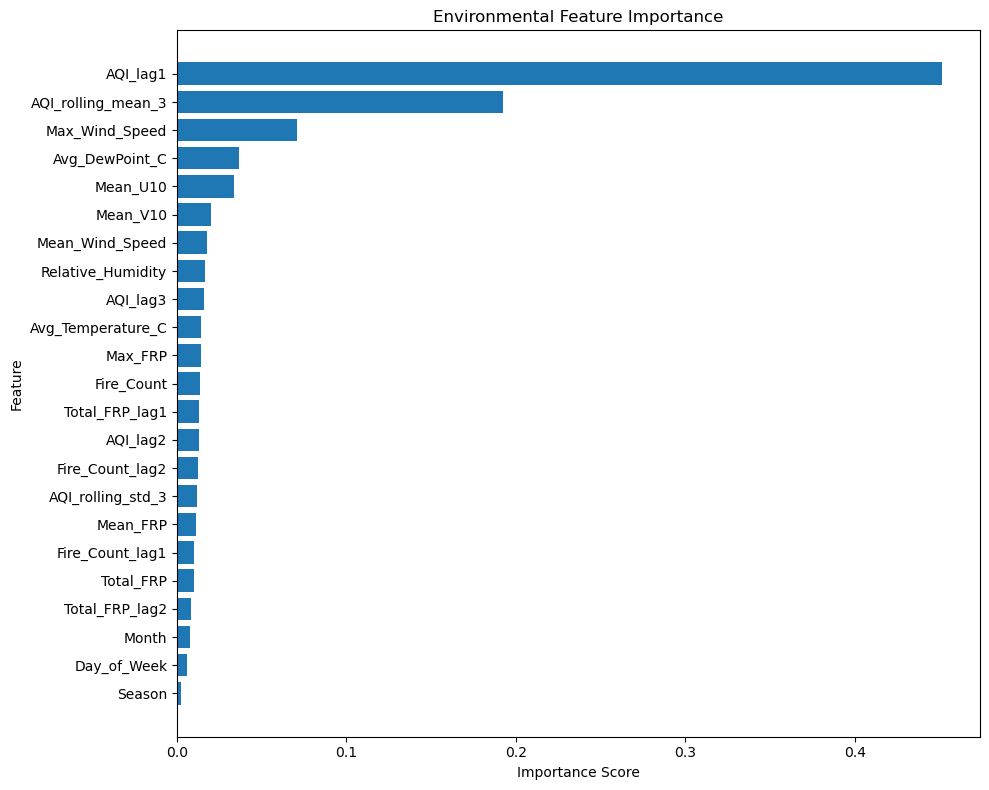

In [11]:
plt.figure(figsize=(10, 8))

plt.barh(
    env_feature_importance["Feature"],
    env_feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Environmental Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## 8. Environmental-Only Feature Importance

Although historical AQI variables are highly informative for forecasting next-day AQI, they primarily represent the persistence of air pollution rather than the influence of environmental factors.

To isolate the contribution of biomass burning and meteorological conditions, all AQI-related variables are excluded from this analysis. The resulting model is not intended to replace the final predictive model but rather to improve the interpretation of environmental drivers influencing next-day AQI.

In [12]:
X_environment = feature_df.drop(
    columns=[
        "Date",
        "AQI_next_day",
        "AQI",
        "AQI_Bucket",
        "PM2.5",
        "AQI_lag1",
        "AQI_lag2",
        "AQI_lag3",
        "AQI_rolling_mean_3",
        "AQI_rolling_std_3"
    ]
)

y = feature_df["AQI_next_day"]

print(X_environment.shape)

(1847, 18)


In [13]:
split_index = int(len(feature_df) * 0.8)

X_train = X_environment.iloc[:split_index]
X_test = X_environment.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [14]:
environment_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

environment_rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
environment_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": environment_rf.feature_importances_
})

environment_importance = environment_importance.sort_values(
    by="Importance",
    ascending=False
)

environment_importance

,Feature,Importance
9,Avg_DewPoint_C,0.391881
11,Month,0.130115
7,Max_Wind_Speed,0.081457
10,Relative_Humidity,0.053168
4,Mean_U10,0.039910
8,Avg_Temperature_C,0.037790
0,Fire_Count,0.032463
5,Mean_V10,0.032029
6,Mean_Wind_Speed,0.029603
15,Fire_Count_lag2,0.026075


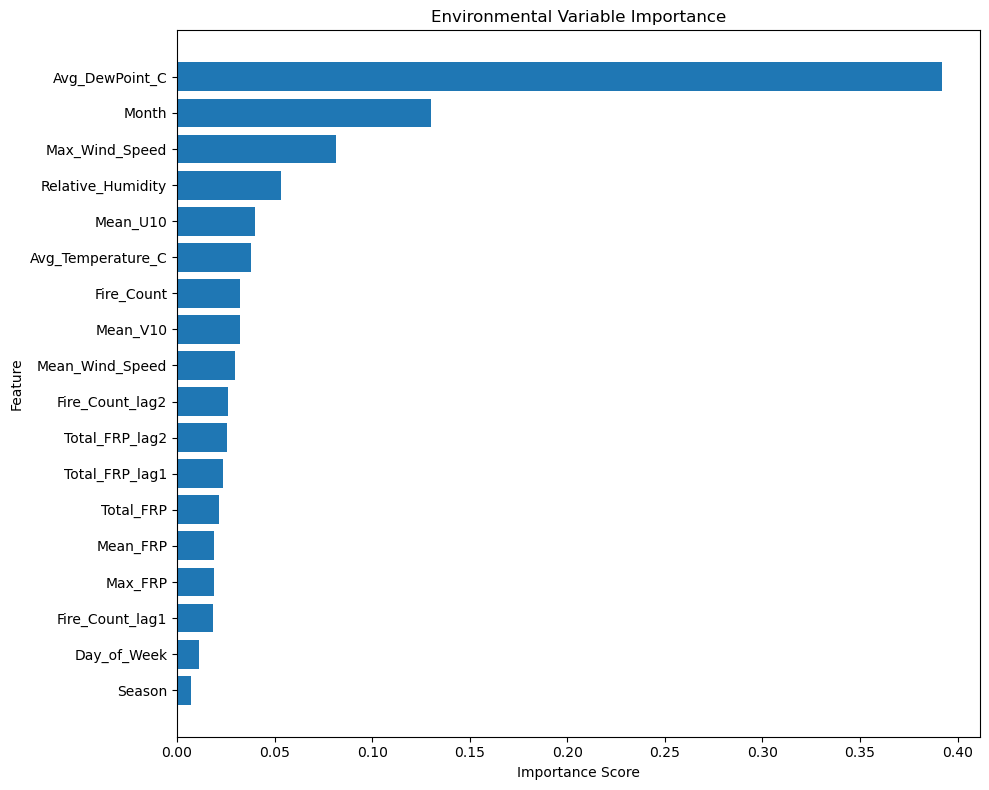

In [16]:
plt.figure(figsize=(10,8))

plt.barh(
    environment_importance["Feature"],
    environment_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Environmental Variable Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()

plt.show()

### Findings

After excluding all current and historical AQI-related variables, the feature importance analysis highlights the relative contribution of environmental variables to next-day AQI prediction.

Average dew point temperature emerged as the most influential environmental predictor, followed by month, maximum wind speed, relative humidity, and wind components. Fire-related variables, including Fire_Count and Total_FRP, also contributed to the model, although their importance was lower than that of the meteorological variables.

These findings suggest that meteorological conditions play a major role in influencing next-day AQI, while biomass burning provides additional predictive information when considered alongside weather variables.

## 9. SHAP Analysis

Feature importance identifies which variables contribute most to the prediction, but it does not explain how individual variables influence the predicted AQI.

SHAP (SHapley Additive exPlanations) is therefore used to interpret the environmental Random Forest model. SHAP assigns an importance value to each feature for every prediction, allowing both the magnitude and direction of each variable's contribution to be examined.

In [17]:
explainer = shap.TreeExplainer(environment_rf)

shap_values = explainer.shap_values(X_test)

In [18]:
print(shap_values.shape)

(370, 18)


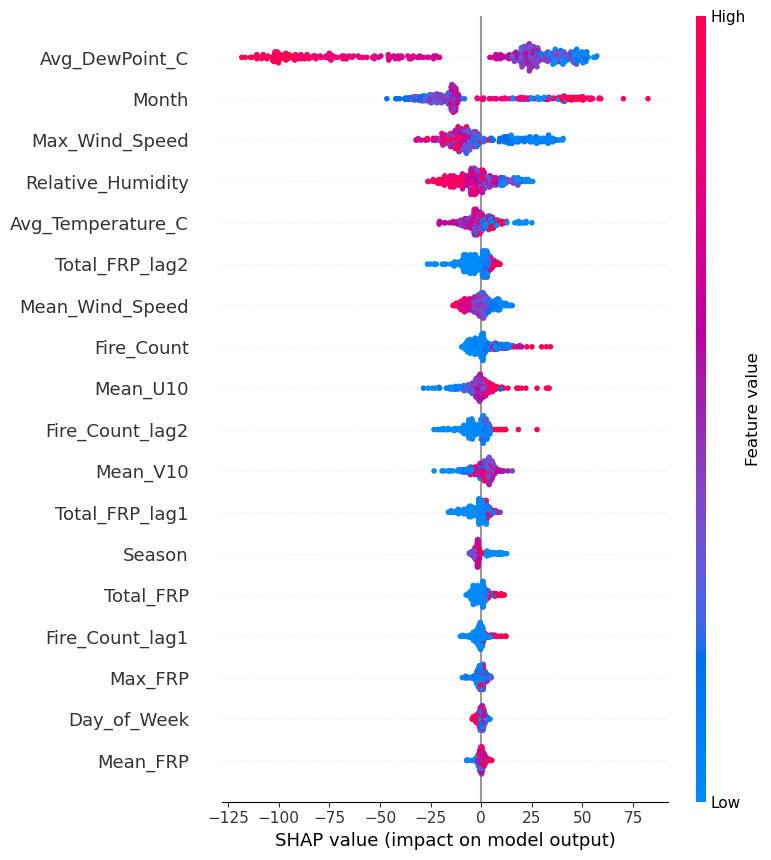

In [19]:
shap.summary_plot(
    shap_values,
    X_test
)

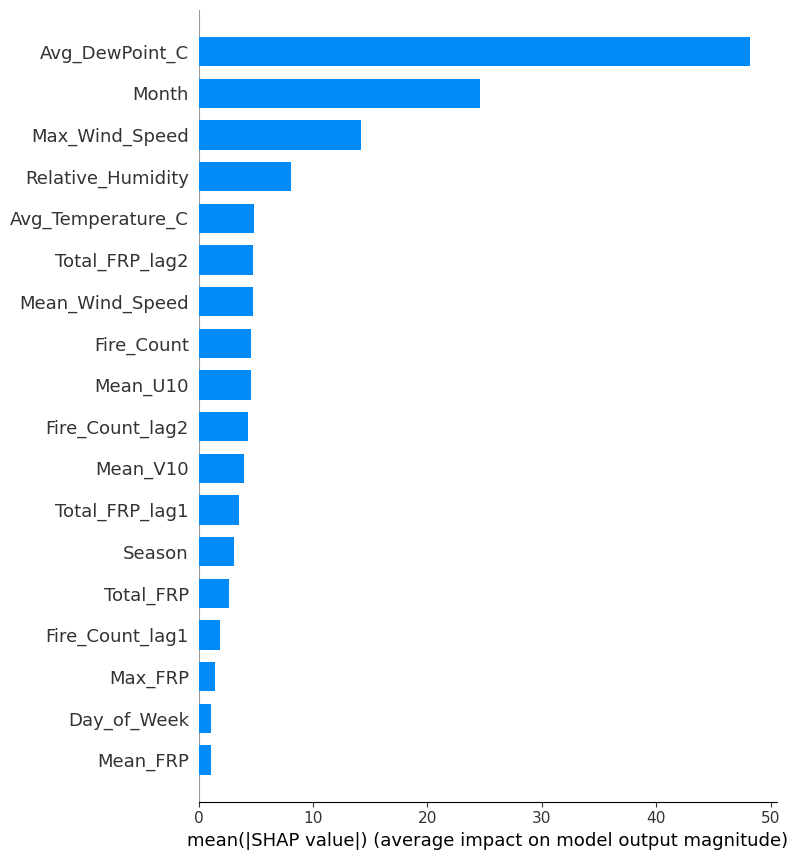

In [20]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

## 10. SHAP Dependence Analysis

While the SHAP summary plot provides an overview of feature importance and direction, dependence plots illustrate how changes in individual variables influence the predicted AQI.

The dependence plots are generated for the most influential environmental variables identified in the previous analysis.

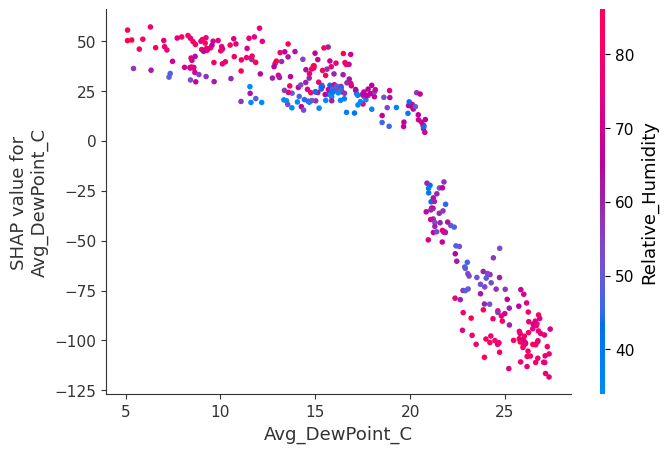

In [22]:
shap.dependence_plot(
    "Avg_DewPoint_C",
    shap_values,
    X_test
)

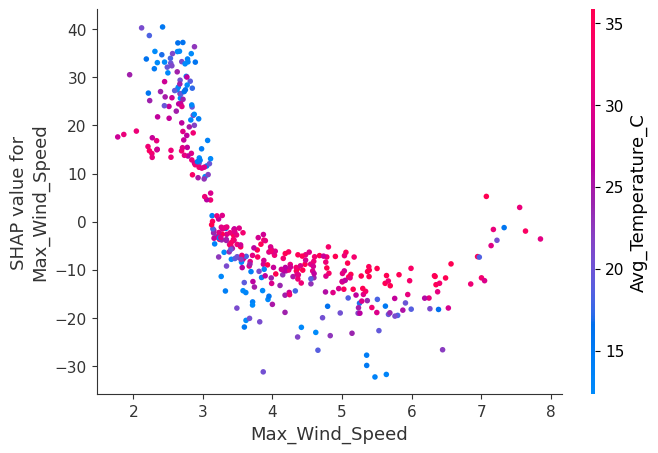

In [23]:
shap.dependence_plot(
    "Max_Wind_Speed",
    shap_values,
    X_test
)

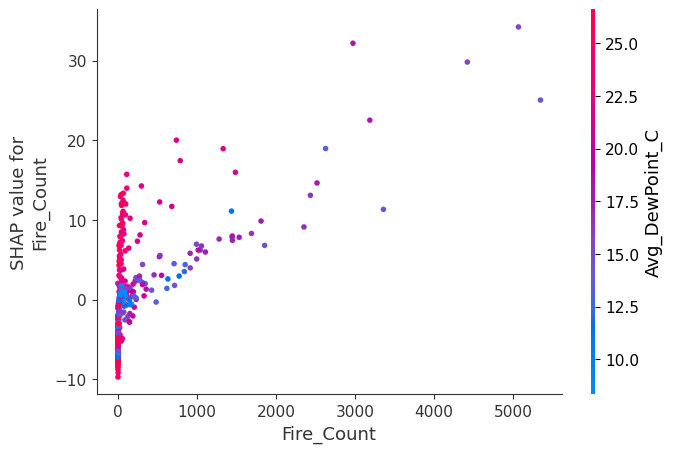

In [24]:
shap.dependence_plot(
    "Fire_Count",
    shap_values,
    X_test
)

### Findings

The SHAP dependence plots provide insight into how the most influential environmental variables affect the predicted AQI.

- Lower dew point values generally increase the predicted AQI, whereas higher dew point values decrease the prediction.
- Increasing maximum wind speed produces increasingly negative SHAP values, indicating that stronger winds reduce predicted AQI by enhancing pollutant dispersion.
- Fire_Count exhibits a positive relationship with predicted AQI. As the number of detected fire events increases, the model predicts higher AQI values, suggesting that biomass burning contributes to deteriorating air quality.

Overall, the SHAP analysis demonstrates that meteorological variables primarily regulate AQI through atmospheric dispersion and moisture conditions, while biomass burning contributes additional increases in predicted pollution levels.

# 11. Hypothesis Validation

The hypotheses proposed at the beginning of the study are evaluated using evidence obtained from exploratory data analysis, statistical analysis, machine learning models, feature importance, and SHAP interpretation.

## Hypothesis 1

### H1: Regional biomass burning has a significant influence on Delhi's next-day AQI.

**Evidence**

- Exploratory Data Analysis indicated a positive relationship between fire activity and AQI.
- Spearman correlation analysis showed a statistically significant positive correlation between Fire_Count and AQI_next_day.
- Multiple Linear Regression identified Fire_Count as a statistically significant predictor.
- Feature importance analysis indicated that fire-related variables contributed to AQI prediction.
- SHAP analysis demonstrated that increasing Fire_Count generally increases the predicted AQI.

### Conclusion

**Supported**

## Hypothesis 2

### H2: Meteorological variables significantly influence Delhi's next-day AQI.

**Evidence**

- Statistical analysis identified temperature, humidity, wind speed, and dew point as significant variables.
- Environmental feature importance ranked Avg_DewPoint_C, Max_Wind_Speed, and Relative_Humidity among the most influential predictors.
- SHAP analysis showed that higher wind speed generally reduces predicted AQI, while dew point also has a strong influence on model predictions.

### Conclusion

**Supported**

## Hypothesis 3

### H3: Machine learning models can accurately predict Delhi's next-day AQI.

**Evidence**

- The tuned Random Forest model achieved the best predictive performance among all evaluated models.
- Performance Metrics:
  - MAE = **28.34**
  - RMSE = **39.63**
  - R² = **0.8767**
- The model demonstrated strong predictive capability for next-day AQI forecasting.

### Conclusion

**Supported**

### Findings

All three research hypotheses are supported by the findings of this study. Biomass burning and meteorological variables contribute significantly to next-day AQI prediction, while the tuned Random Forest model demonstrated strong forecasting performance. SHAP analysis further confirmed the influence of environmental variables on the model's predictions.

# 12. Research Questions

The findings obtained from exploratory data analysis, statistical analysis, machine learning models, feature importance, and SHAP interpretation are used to answer the research questions proposed for this study.

## Research Question 1

### Does regional biomass burning contribute to Delhi's next-day AQI?

**Answer**

Yes. The analysis indicates that biomass burning contributes to next-day AQI prediction. Statistical analysis identified a significant relationship between Fire_Count and AQI_next_day. Feature importance analysis also highlighted the contribution of fire-related variables. Furthermore, SHAP analysis showed that increasing Fire_Count generally increases the predicted AQI, confirming that biomass burning has a measurable influence on air quality.

## Research Question 2

### Which environmental variables contribute the most to next-day AQI prediction?

**Answer**

Among the environmental variables evaluated, Avg_DewPoint_C emerged as the most influential predictor, followed by Month, Max_Wind_Speed, Relative_Humidity, Mean_U10, and Avg_Temperature_C. Fire_Count also contributed to the prediction, although its influence was lower than that of the major meteorological variables. These findings indicate that both atmospheric conditions and biomass burning jointly influence next-day AQI.

## Research Question 3

### Can machine learning accurately predict Delhi's next-day AQI?

**Answer**

Yes. Among all the evaluated machine learning models, the tuned Random Forest achieved the best predictive performance with an MAE of **28.34**, RMSE of **39.63**, and an R² score of **0.8767**. These results demonstrate that machine learning can accurately forecast Delhi's next-day AQI when historical air quality, biomass burning, and meteorological variables are incorporated.

### Findings

The research questions were successfully addressed using the results obtained throughout the study. Biomass burning and meteorological variables both contribute to AQI prediction, while meteorological conditions exhibited a stronger influence among the environmental variables. The tuned Random Forest model demonstrated strong predictive performance and, together with SHAP analysis, provided an interpretable framework for understanding the environmental drivers of Delhi's next-day AQI.

# 13. Conclusion

This study developed an end-to-end machine learning framework for predicting Delhi's next-day Air Quality Index (AQI) by integrating air quality observations, NASA FIRMS biomass burning data, and ERA5 meteorological variables. The workflow included data collection, preprocessing, exploratory data analysis, feature engineering, statistical analysis, machine learning modelling, and model interpretation.

Among the evaluated machine learning models, the tuned Random Forest achieved the best predictive performance with an MAE of **28.34**, RMSE of **39.63**, and an R² score of **0.8767**, demonstrating strong capability for next-day AQI forecasting.

## Key Findings

- The tuned Random Forest model outperformed Linear Regression and XGBoost for next-day AQI prediction.
- Historical AQI variables were the strongest predictors of future AQI, indicating strong temporal persistence in air pollution.
- Among the environmental variables, Avg_DewPoint_C, Month, Max_Wind_Speed, Relative_Humidity, and Avg_Temperature_C were the most influential predictors.
- Biomass burning variables, including Fire_Count and Total_FRP, contributed positively to AQI prediction, although their influence was lower than the major meteorological variables.
- SHAP analysis improved the interpretability of the model by explaining how environmental variables influenced individual AQI predictions.

## Limitations

- The study was conducted using historical data from Delhi for the selected study period and may not fully capture future environmental changes.
- Biomass burning was represented using satellite-detected fire activity and FRP, which may not capture every local pollution source affecting Delhi.
- The prediction model focuses on one-day-ahead forecasting and relies on information available up to the current day.
- Additional environmental variables such as boundary layer height, emission inventories, and traffic intensity were not included and could further improve prediction performance.

## Future Work

Future studies can extend this work by incorporating additional atmospheric and emission-related variables, exploring deep learning models such as LSTM and Transformer networks for multi-day AQI forecasting, and evaluating the framework across multiple Indian cities. Integrating real-time monitoring data and advanced explainable AI techniques could further improve both prediction accuracy and model interpretability for operational air quality management.

### Final Remarks

This study demonstrates that combining machine learning with environmental and biomass burning data provides an effective framework for next-day AQI prediction. The integration of explainable AI techniques, including feature importance and SHAP analysis, not only improved the transparency of the predictive model but also provided valuable insights into the environmental factors influencing Delhi's air quality. The proposed framework can support environmental monitoring, pollution management, and informed decision-making for improving urban air quality.